# The Hiring Problem (Optimal Stopping Problem for sequential sampling)

This notebook explores the famous **secretary problem**, a classic problem in optimal stopping theory.

## The Problem

Imagine you need to hire a secretary from 100 candidates. The candidates arrive sequentially, and you must:
- Interview them one at a time in random order
- Immediately accept or reject each candidate (no callbacks)
- Cannot compare candidates you haven't seen yet

**Goal:** Maximize the probability of selecting the best candidate.

## The Optimal Strategy

The solution is to:
1. **Reject the first n candidates** (the "sampling phase") and note the best quality among them
2. **Select the first subsequent candidate** who is better than all candidates in the sampling phase

## Key Question

What value of n maximizes your chance of selecting the best candidate?

**Theoretical answer:** n ≈ N/e ≈ 37% of all candidates, which gives a success probability of approximately 1/e ≈ 37%.

## Model and Monte Carlo Simulation

* The quality of the candidate is represented by a single number drawn from a standard normal; higher numbers represent better candidates
* Randomness will play a role. E.g. sometimes the best candidate comes early in the process and you reject them
* Perform enough trials to give a good estimate of the average outcome for the strategies
* Show that the optimal stopping strategy is given above and estimate the outcomes to see if they match the theoretical outcome

Every trial pool is evaluated at every decision point, so the strategies are compared on the same candidates.
If nobody after the sampling phase beats the bar, you are stuck with the last candidate.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(1001)

candidate_pool_size = 100  # N candidates per pool
trials = 8000              # pools simulated
decision_points = np.arange(1, candidate_pool_size)  # candidates rejected in the sampling phase


def run_strategies(pools):
    """Apply the "reject the first d, then take the first better one" rule for every d.

    pools: (trials, N) candidate qualities, in interview order.
    Returns (selected index, selected quality), each shaped (len(decision_points), trials).
    """
    n_trials, n = pools.shape
    bar = np.maximum.accumulate(pools, axis=1)  # bar[:, d-1] = best of the first d candidates
    selected = np.empty((len(decision_points), n_trials), dtype=int)
    for i, d in enumerate(decision_points):
        better = pools[:, d:] > bar[:, d - 1, None]
        selected[i] = np.where(better.any(axis=1), d + better.argmax(axis=1), n - 1)
    quality = np.take_along_axis(pools, selected.T, axis=1).T
    return selected, quality


pools = rng.normal(0, 1, size=(trials, candidate_pool_size))
selected, quality = run_strategies(pools)
best = pools.max(axis=1)
fraction_best = quality / best   # quality ratio: selected / best in the pool
got_best = quality == best

Random selection of a candidate:

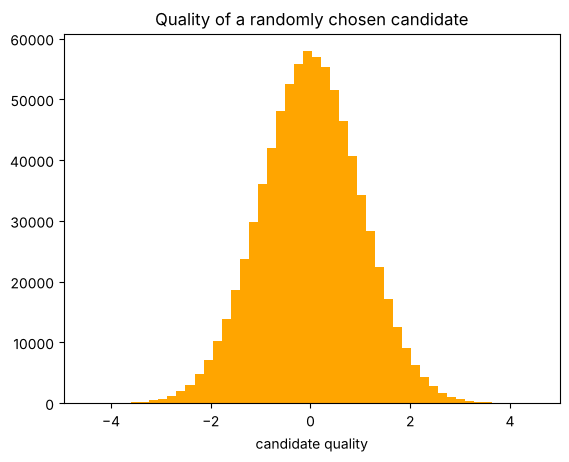

In [2]:
plt.hist(pools.ravel(), bins=50, color="orange")
plt.xlabel("candidate quality")
plt.title("Quality of a randomly chosen candidate")
plt.show()

Distribution of the hired candidate's quality as the decision point moves from 1 to 99 (each column sums to 1).
Notice that waiting for even 1 candidate to set the bar improves outcomes significantly. The benefits of waiting
are erased in the 60s.

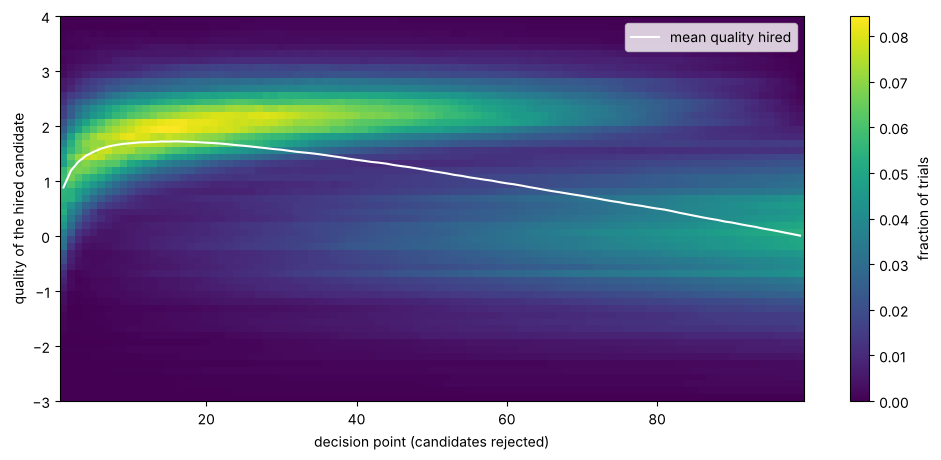

In [3]:
bins = np.linspace(-3, 4, 57)
hist = np.stack([np.histogram(q, bins=bins)[0] / trials for q in quality], axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(hist, origin="lower", aspect="auto", cmap="viridis",
               extent=(0.5, candidate_pool_size - 0.5, bins[0], bins[-1]))
fig.colorbar(im, ax=ax, label="fraction of trials")
ax.plot(decision_points, quality.mean(axis=1), "w-", lw=1.5, label="mean quality hired")
ax.set_xlabel("decision point (candidates rejected)")
ax.set_ylabel("quality of the hired candidate")
ax.legend(loc="upper right")
plt.show()

## Plot 1: Probability of Selecting the Best Candidate

This plot shows the **probability of successfully selecting the best candidate** as a function of the sample size (number of candidates rejected in the sampling phase).

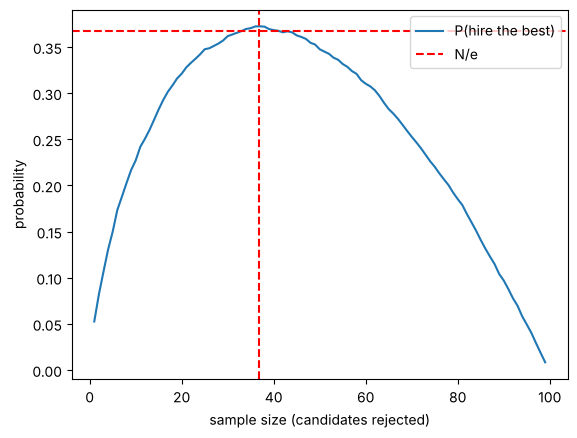

In [4]:
fig, ax = plt.subplots()
ax.plot(decision_points, got_best.mean(axis=1), label="P(hire the best)")
ax.axvline(x=candidate_pool_size / np.e, color="red", linestyle="--", label="N/e")
ax.axhline(y=1 / np.e, color="red", linestyle="--")
ax.set_xlabel("sample size (candidates rejected)")
ax.set_ylabel("probability")
ax.legend()
plt.show()

### Interpretation:

- **Red dashed lines** mark the theoretical optimum:
  - **Vertical line at N/e ≈ 37**: The optimal number of candidates to reject (sample size)
  - **Horizontal line at 1/e ≈ 37%**: The maximum achievable probability of success

- **Peak Performance**: The curve reaches its maximum around sample size 37, confirming the theoretical prediction
- **Too Few Samples**: If you reject too few candidates (left side), you don't have enough information to identify quality
- **Too Many Samples**: If you reject too many candidates (right side), the best candidate may have already passed

This demonstrates that the optimal strategy is to **reject approximately the first 37%** of candidates, then select the next one who's better than all previous ones.

## Plot 2: Average Position of Selected Candidate

This plot shows the **average position (index)** of the candidate selected using each sample size strategy,
and the full distribution of positions for sample sizes 37 and 13.

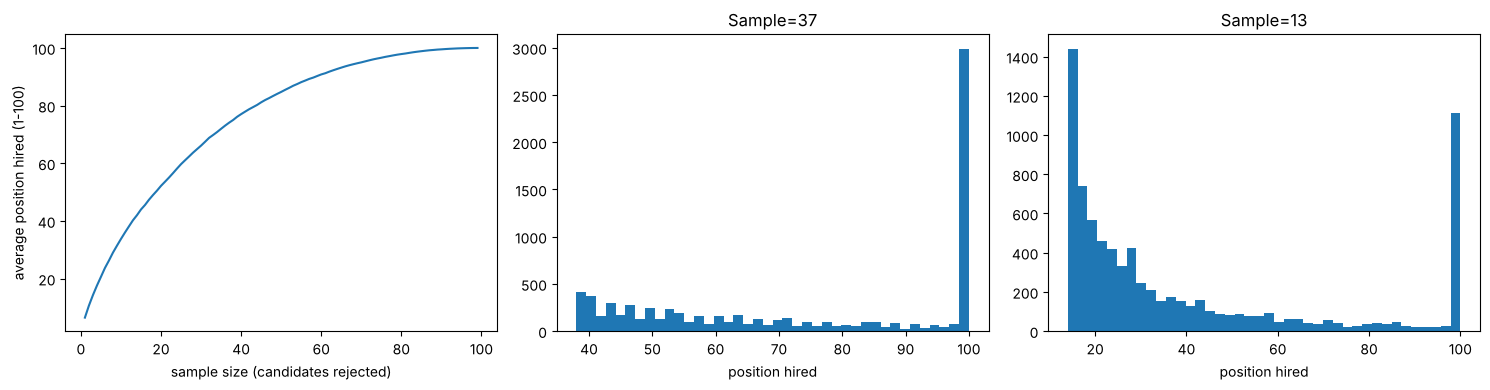

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(decision_points, selected.mean(axis=1) + 1)
axes[0].set_xlabel("sample size (candidates rejected)")
axes[0].set_ylabel("average position hired (1-100)")
for ax, d in zip(axes[1:], (37, 13)):
    ax.hist(selected[d - 1] + 1, bins=40)
    ax.set_title(f"Sample={d}")
    ax.set_xlabel("position hired")
plt.tight_layout()
plt.show()

### Interpretation:

- **X-axis**: Sample size (number of candidates rejected before selecting)
- **Y-axis**: Average position where selection occurs (1-100)

**Key Observations:**
- **Small sample sizes**: When you reject few candidates (left), you select early (low index) because you quickly find someone better than the small sample
- **Large sample sizes**: When you reject many candidates (right), you're forced to select later (high index) or reach the end
- **Optimal region (around 37)**: Balances between having enough information and having enough remaining candidates

The curve shows that with the optimal strategy, you typically select around position 75 on average, giving you plenty of candidates to evaluate while still having options remaining.

## Plot 3: Average Quality Ratio of Selected Candidate
This plot shows the average quality ratio (selected candidate's quality / best candidate's quality) as a function of sample size.
One might argue this is the optimal stopping point if the goal is to consistently hire the highest possible quality candidates.

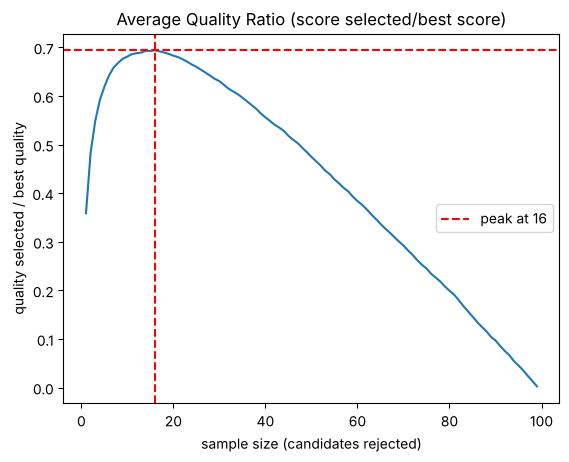

Peak average quality ratio 0.694 at sample size 16


In [6]:
mean_ratio = fraction_best.mean(axis=1)
d_best = decision_points[mean_ratio.argmax()]

fig, ax = plt.subplots()
ax.plot(decision_points, mean_ratio)
ax.axvline(x=d_best, color="red", linestyle="--", label=f"peak at {d_best}")
ax.axhline(y=mean_ratio.max(), color="red", linestyle="--")
ax.set_xlabel("sample size (candidates rejected)")
ax.set_ylabel("quality selected / best quality")
ax.set_title("Average Quality Ratio (score selected/best score)")
ax.legend()
plt.show()
print(f"Peak average quality ratio {mean_ratio.max():.3f} at sample size {d_best}")

### Interpretation:

- **Y-axis value of 1.0** means you selected the absolute best candidate
- **Y-axis value < 1.0** means you selected a good but not optimal candidate

**Key Observations:**
- The curve has a similar shape to Plot 1, but peaks much earlier, around a sample size of 10-20
- **Peak around 0.69**: Even with the best sample size, on average you hire a candidate whose quality is about 69% of the best
- **This differs from Plot 1**: Plot 1 shows the probability of getting exactly the best (binary success), while this plot shows the average quality of whoever you select

**Why the difference?**

Plot 1 scores a near-miss the same as a disaster. When you sample for a long time, the best candidate is often
in the sample, nobody later beats the bar, and you are forced to take the last candidate, an average one. If what
you care about is the quality of the hire, it pays to stop sampling earlier: you give up some chance of the very best
candidate in exchange for a much smaller chance of a poor one.

## Summary: Average Quality Ratio at Optimal Stopping Strategy

Calculate the average quality ratio of the selected candidate when using the optimal stopping strategy (rejecting approximately N/e candidates).

In [7]:
optimal_sample = round(candidate_pool_size / np.e)
ratio = fraction_best[optimal_sample - 1]
print(f"Optimal decision point: {optimal_sample} (N/e = {candidate_pool_size / np.e:.2f})")
print(f"\nUsing the optimal stopping strategy (rejecting first {optimal_sample} candidates):")
print(f"P(hire the best candidate):                  {got_best[optimal_sample - 1].mean():.4f}  (theory 1/e = {1 / np.e:.4f})")
print(f"Average quality ratio of selected candidate: {ratio.mean():.4f}")
print(f"Standard deviation:                          {ratio.std():.4f}")
print(f"\nOn average, the selected candidate's quality is {ratio.mean():.1%} of the best candidate,")
print(f"below the {mean_ratio.max():.1%} reached by sampling only {d_best} candidates.")

Optimal decision point: 37 (N/e = 36.79)

Using the optimal stopping strategy (rejecting first 37 candidates):
P(hire the best candidate):                  0.3725  (theory 1/e = 0.3679)
Average quality ratio of selected candidate: 0.5812
Standard deviation:                          0.5187

On average, the selected candidate's quality is 58.1% of the best candidate,
below the 69.4% reached by sampling only 16 candidates.
